# Security, Compliance & Responsible AI in Production
### Live Demo Notebook — Companion to the 1-Hour Session (Week 11)

This notebook contains four independent demo blocks, each tied to a section of the session deck.
Every block is self-contained — you can run any single block without running the others first.

| Block | Section | Dataset |
|---|---|---|
| 1 | Model Security — extraction, membership inference, poisoning, OOD, infrastructure | Breast Cancer Wisconsin (scikit-learn) |
| 2 | Data Privacy — PII anonymisation | Adult Income (UCI, via the `shap` library) |
| 3 | Responsible AI — fairness & explainability | NHANES-I Health Survey (UCI, via the `shap` library) |
| 4 | Case Study — drift + fairness monitoring | Diabetes (scikit-learn) |

**Note on datasets:** the session plan called for the German Credit dataset in Block 3. That dataset
is hosted on the UCI repository and OpenML, which aren't reachable from this environment's network
allowlist. NHANES-I (a real health survey with age and sex attributes, bundled with the `shap`
library) is used instead — it supports the same fairness + explainability workflow on real data.

**Toolchain:** pandas, numpy, scikit-learn, fairlearn, shap, joblib, matplotlib, ipywidgets.

In [1]:
# Environment check — run this first
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Consistent visual style across all four blocks
NAVY = "#0B2545"
TEAL = "#1C7293"
TEAL_LIGHT = "#4FA9C9"
ALERT = "#D9724C"
MUTED = "#6E85A3"

mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["axes.edgecolor"] = MUTED
mpl.rcParams["axes.labelcolor"] = NAVY
mpl.rcParams["text.color"] = NAVY
mpl.rcParams["xtick.color"] = NAVY
mpl.rcParams["ytick.color"] = NAVY
mpl.rcParams["axes.titlecolor"] = NAVY
mpl.rcParams["font.size"] = 11

print("Environment ready.")

Environment ready.


---
## Block 1 — Model Security: All Four Threat Buckets

**Dataset:** Breast Cancer Wisconsin (569 records, 30 numeric features, binary diagnosis).

**What we'll do**, one sub-demo per threat bucket from the deck:
1. **Model & privacy threats** — clone a model via a black-box extraction attack, then compute a membership inference score
2. **Data threats** — inject label noise (poisoning) and watch accuracy degrade
3. **Input threats** — build a simple out-of-distribution (OOD) detector and test it
4. **Infrastructure & access threats** — a query-rate anomaly detector that would have caught the extraction attack

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import joblib

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

baseline_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
baseline_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, baseline_model.predict(X_train))
test_acc = accuracy_score(y_test, baseline_model.predict(X_test))

joblib.dump(baseline_model, "breast_cancer_baseline.joblib")

print(f"Training accuracy: {train_acc:.3f}")
print(f"Held-out test accuracy: {test_acc:.3f}")
print(f"Feature count: {X.shape[1]}")

Training accuracy: 0.998
Held-out test accuracy: 0.958
Feature count: 30


### 1.1 — Model & privacy threats: simulating a model extraction attack

We treat `deployed_model_query()` as the only access an attacker has — a black-box API that returns
a prediction for a given input. The attacker never sees the model's weights or training data.

In [3]:
deployed_model = joblib.load("breast_cancer_baseline.joblib")
feature_names = X.columns.tolist()

def deployed_model_query(X_query):
    """Simulates calling a deployed model's prediction API."""
    return deployed_model.predict(X_query)

# --- Attacker's side: no access to training data or labels, only to the query API ---
# The attacker samples plausible-looking inputs by bootstrapping each feature's marginal
# distribution independently (e.g. from public summary statistics) — far more realistic
# than pure uniform-random noise, and much more damaging.
rng = np.random.default_rng(7)
N_QUERIES = 1500

synthetic_queries = pd.DataFrame(
    {col: rng.choice(X_train[col].values, N_QUERIES, replace=True) for col in feature_names}
)
stolen_labels = deployed_model_query(synthetic_queries)

surrogate_model = DecisionTreeClassifier(max_depth=6, random_state=42)
surrogate_model.fit(synthetic_queries, stolen_labels)

print(f"Queries sent to the API: {N_QUERIES}")
print("Surrogate model trained on stolen input-output pairs only.")

Queries sent to the API: 1500
Surrogate model trained on stolen input-output pairs only.


In [4]:
surrogate_predictions = surrogate_model.predict(X_test)
target_predictions = deployed_model_query(X_test)

fidelity = accuracy_score(target_predictions, surrogate_predictions)
surrogate_real_world_acc = accuracy_score(y_test, surrogate_predictions)

print(f"Surrogate vs. target agreement (fidelity): {fidelity:.1%}")
print(f"Surrogate accuracy on real held-out labels:  {surrogate_real_world_acc:.1%}")
print(f"Original model accuracy on the same data:    {test_acc:.1%}")
print()
print("Interpretation: the attacker never saw a single real training record or label, only")
print(f"{N_QUERIES} query responses — yet the surrogate model matches the deployed model's")
print("predictions on unseen data almost exactly. This is what makes rate limiting, output")
print("perturbation, and query-pattern monitoring necessary defenses, not optional ones.")

Surrogate vs. target agreement (fidelity): 99.3%
Surrogate accuracy on real held-out labels:  95.1%
Original model accuracy on the same data:    95.8%

Interpretation: the attacker never saw a single real training record or label, only
1500 query responses — yet the surrogate model matches the deployed model's
predictions on unseen data almost exactly. This is what makes rate limiting, output
perturbation, and query-pattern monitoring necessary defenses, not optional ones.


### 1.2 — Membership inference: does the model "remember" its training data?

Mean confidence on TRAINING records: 0.966
Mean confidence on HELD-OUT records:  0.935


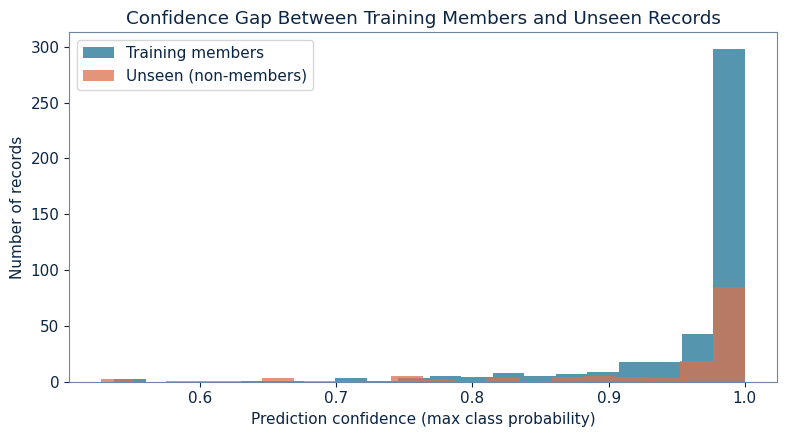

In [5]:
train_confidence = baseline_model.predict_proba(X_train).max(axis=1)
test_confidence = baseline_model.predict_proba(X_test).max(axis=1)

print(f"Mean confidence on TRAINING records: {train_confidence.mean():.3f}")
print(f"Mean confidence on HELD-OUT records:  {test_confidence.mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(train_confidence, bins=20, alpha=0.75, color=TEAL, label="Training members")
ax.hist(test_confidence, bins=20, alpha=0.75, color=ALERT, label="Unseen (non-members)")
ax.set_xlabel("Prediction confidence (max class probability)")
ax.set_ylabel("Number of records")
ax.set_title("Confidence Gap Between Training Members and Unseen Records")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import roc_auc_score

labels_membership = np.concatenate([np.ones(len(train_confidence)), np.zeros(len(test_confidence))])
scores_membership = np.concatenate([train_confidence, test_confidence])
attack_auc = roc_auc_score(labels_membership, scores_membership)

threshold = 0.99
attack_predictions = (scores_membership > threshold).astype(int)
attack_accuracy = (attack_predictions == labels_membership).mean()

print(f"Membership inference attack AUC:        {attack_auc:.3f}  (0.5 = no leakage, 1.0 = full leakage)")
print(f"Attack accuracy at confidence > {threshold}: {attack_accuracy:.1%}")
print()
print("An AUC meaningfully above 0.5 confirms the model leaks membership information.")
print("Defenses: differential privacy during training, regularization, confidence rounding.")

Membership inference attack AUC:        0.587  (0.5 = no leakage, 1.0 = full leakage)
Attack accuracy at confidence > 0.99: 58.3%

An AUC meaningfully above 0.5 confirms the model leaks membership information.
Defenses: differential privacy during training, regularization, confidence rounding.


### 1.3 — Data threats: poisoning training data with label noise

We simulate an attacker (or just a low-quality labeling pipeline) flipping a fraction of training
labels at random, then retrain from scratch at each noise level to see how quickly accuracy erodes.

In [7]:
def poison_labels(y, poison_rate, seed=0):
    rng_local = np.random.default_rng(seed)
    y_poisoned = y.copy().reset_index(drop=True) if hasattr(y, "reset_index") else np.array(y).copy()
    n_flip = int(len(y_poisoned) * poison_rate)
    flip_idx = rng_local.choice(len(y_poisoned), size=n_flip, replace=False)
    y_poisoned = np.array(y_poisoned)
    y_poisoned[flip_idx] = 1 - y_poisoned[flip_idx]
    return y_poisoned

poison_rates = [0.0, 0.05, 0.10, 0.20, 0.30]
poisoned_accuracies = []

for rate in poison_rates:
    y_train_poisoned = poison_labels(y_train, rate, seed=42)
    poisoned_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    poisoned_model.fit(X_train, y_train_poisoned)
    acc = accuracy_score(y_test, poisoned_model.predict(X_test))
    poisoned_accuracies.append(acc)
    print(f"Label noise rate {rate:.0%}: held-out accuracy = {acc:.3f}")

Label noise rate 0%: held-out accuracy = 0.958


Label noise rate 5%: held-out accuracy = 0.958


Label noise rate 10%: held-out accuracy = 0.965


Label noise rate 20%: held-out accuracy = 0.944


Label noise rate 30%: held-out accuracy = 0.909


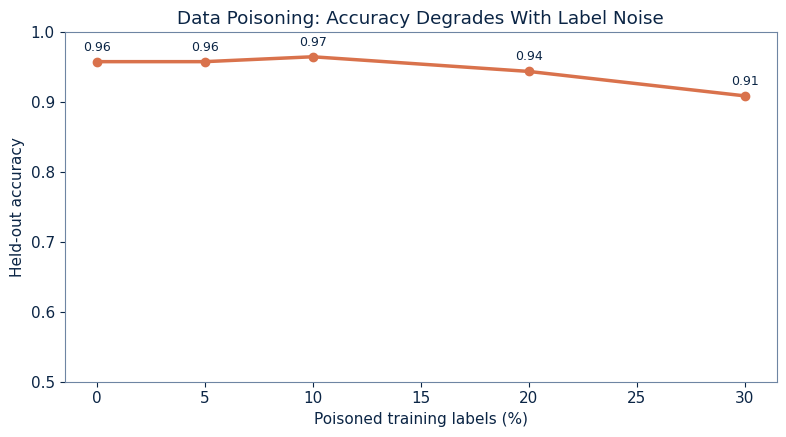


Even a modest amount of label noise meaningfully erodes accuracy on clean, held-out data.
Defenses: data validation pipelines, anomaly detection on incoming data, provenance tracking.


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([r * 100 for r in poison_rates], poisoned_accuracies, marker="o", color=ALERT, linewidth=2.5)
ax.set_xlabel("Poisoned training labels (%)")
ax.set_ylabel("Held-out accuracy")
ax.set_title("Data Poisoning: Accuracy Degrades With Label Noise")
ax.set_ylim(0.5, 1.0)
for r, a in zip(poison_rates, poisoned_accuracies):
    ax.annotate(f"{a:.2f}", (r * 100, a), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print()
print("Even a modest amount of label noise meaningfully erodes accuracy on clean, held-out data.")
print("Defenses: data validation pipelines, anomaly detection on incoming data, provenance tracking.")

### 1.4 — Input threats: a simple out-of-distribution (OOD) detector

Rather than trusting every input the model receives, we build a lightweight statistical check that
flags inputs that don't look like anything the model was trained on — before they ever reach it.

In [9]:
# Fit a simple Gaussian model (mean + covariance) on the training feature distribution
train_mean = X_train.mean().values
train_cov = np.cov(X_train.values, rowvar=False)
train_cov_inv = np.linalg.pinv(train_cov + np.eye(train_cov.shape[0]) * 1e-6)

def mahalanobis_score(X_query):
    diffs = X_query.values - train_mean
    return np.einsum("ij,jk,ik->i", diffs, train_cov_inv, diffs)

# Establish a detection threshold from the training data itself (e.g. 99th percentile)
train_scores = mahalanobis_score(X_train)
ood_threshold = np.percentile(train_scores, 99)

# In-distribution check: real held-out test data
test_scores = mahalanobis_score(X_test)
false_positive_rate_ood = (test_scores > ood_threshold).mean()

# Out-of-distribution check: synthetic inputs with an unrealistic combination of feature values
rng2 = np.random.default_rng(11)
ood_samples = pd.DataFrame(
    {col: rng2.uniform(X[col].min(), X[col].max(), 200) for col in feature_names}
)
# Push a few features further outside the training range to simulate a more extreme OOD case
for col in feature_names[:5]:
    ood_samples[col] *= 1.8
ood_scores = mahalanobis_score(ood_samples)
detection_rate_ood = (ood_scores > ood_threshold).mean()

print(f"OOD threshold (99th percentile of training scores): {ood_threshold:.1f}")
print(f"False positive rate on real held-out data (flagged as OOD): {false_positive_rate_ood:.1%}")
print(f"Detection rate on synthetic OOD samples:                    {detection_rate_ood:.1%}")

OOD threshold (99th percentile of training scores): 152.3
False positive rate on real held-out data (flagged as OOD): 1.4%
Detection rate on synthetic OOD samples:                    100.0%


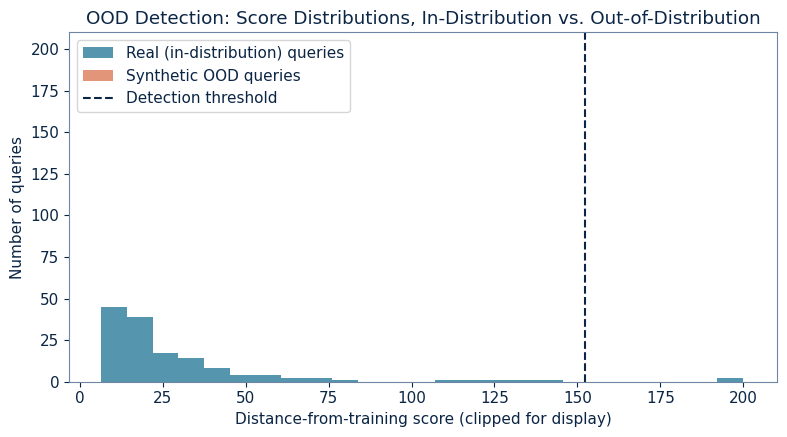


A statistical distance check like this can sit in front of the model as a cheap first
line of defense — flagging or rejecting inputs before they reach a model that was never
validated on data like that.


In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(np.clip(test_scores, 0, 200), bins=25, alpha=0.75, color=TEAL, label="Real (in-distribution) queries")
ax.hist(np.clip(ood_scores, 0, 200), bins=25, alpha=0.75, color=ALERT, label="Synthetic OOD queries")
ax.axvline(min(ood_threshold, 200), color=NAVY, linestyle="--", linewidth=1.5, label="Detection threshold")
ax.set_xlabel("Distance-from-training score (clipped for display)")
ax.set_ylabel("Number of queries")
ax.set_title("OOD Detection: Score Distributions, In-Distribution vs. Out-of-Distribution")
ax.legend()
plt.tight_layout()
plt.show()

print()
print("A statistical distance check like this can sit in front of the model as a cheap first")
print("line of defense — flagging or rejecting inputs before they reach a model that was never")
print("validated on data like that.")

### 1.5 — Infrastructure & access threats: a query-rate anomaly detector

The extraction attack from section 1.1 sent 1,500 queries in one burst. A basic rate-based
monitor on the serving infrastructure would have caught this pattern immediately.

In [11]:
# Simulate two traffic patterns over a 60-minute window, in one-minute buckets
minutes = np.arange(60)

# Normal usage: a handful of queries per minute, occasionally more, but no extreme bursts
rng3 = np.random.default_rng(3)
normal_traffic = rng3.poisson(lam=4, size=60)

# Attack traffic: normal usage for the first 40 minutes, then the 1,500-query burst
# arrives compressed into a 5-minute window starting at minute 40
attack_traffic = normal_traffic.copy()
attack_traffic[40:45] += N_QUERIES // 5

# A simple anomaly threshold: mean + 3 standard deviations of *normal* traffic
baseline_mean = normal_traffic.mean()
baseline_std = normal_traffic.std()
anomaly_threshold = baseline_mean + 3 * baseline_std

flagged_minutes = minutes[attack_traffic > anomaly_threshold]
print(f"Normal traffic: ~{baseline_mean:.1f} queries/minute (std {baseline_std:.1f})")
print(f"Anomaly threshold (mean + 3 std): {anomaly_threshold:.1f} queries/minute")
print(f"Minutes flagged as anomalous: {list(flagged_minutes)}")

Normal traffic: ~4.3 queries/minute (std 1.9)
Anomaly threshold (mean + 3 std): 9.9 queries/minute
Minutes flagged as anomalous: [np.int64(23), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44)]


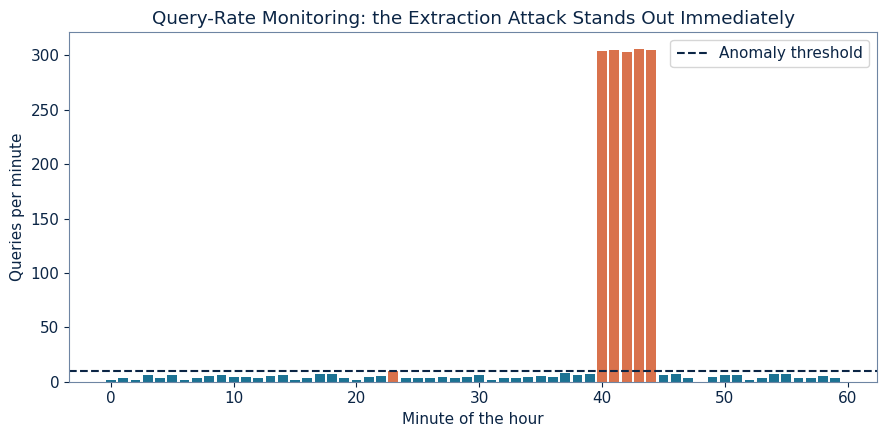


This is the same extraction attack from section 1.1, viewed from the infrastructure side.
Rate limiting and anomaly alerting would have caught it within minutes, not after the fact.


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(minutes, attack_traffic, color=[ALERT if m in flagged_minutes else TEAL for m in minutes])
ax.axhline(anomaly_threshold, color=NAVY, linestyle="--", linewidth=1.5, label="Anomaly threshold")
ax.set_xlabel("Minute of the hour")
ax.set_ylabel("Queries per minute")
ax.set_title("Query-Rate Monitoring: the Extraction Attack Stands Out Immediately")
ax.legend()
plt.tight_layout()
plt.show()

print()
print("This is the same extraction attack from section 1.1, viewed from the infrastructure side.")
print("Rate limiting and anomaly alerting would have caught it within minutes, not after the fact.")

---
## Block 2 — Data Privacy: PII Anonymization

**Dataset:** Adult Income (UCI Census data, ~32,500 records) — realistic quasi-identifiers
(age, occupation, native country, education) make it a natural fit for anonymization trade-offs.

**What we'll do:**
1. Identify direct and quasi-identifiers in the raw dataset
2. Measure re-identification risk from quasi-identifiers alone
3. Apply generalization (k-anonymity style) and masking
4. Compare re-identification risk and data utility before vs. after

In [13]:
import shap

X_adult, y_adult = shap.datasets.adult(display=True)
X_adult = X_adult.reset_index(drop=True)
y_adult = pd.Series(y_adult, name="income_over_50k").reset_index(drop=True)

print(f"Records: {X_adult.shape[0]}, Columns: {X_adult.shape[1]}")
X_adult.head()

Records: 32561, Columns: 12


,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba


### 2.1 — Classifying identifiers

This dataset has no direct identifiers (no names or SSNs), which is common for a released
"anonymized" dataset — but that alone doesn't make it safe. The real risk sits in the
**quasi-identifiers**: fields that aren't identifying alone, but can be combined to re-identify someone.

In [14]:
quasi_identifiers = ["Age", "Workclass", "Education-Num", "Occupation", "Country", "Sex"]

print("Quasi-identifiers selected for this demo:")
for col in quasi_identifiers:
    print(f"  - {col}: {X_adult[col].nunique()} unique values")

Quasi-identifiers selected for this demo:
  - Age: 73 unique values
  - Workclass: 9 unique values
  - Education-Num: 16 unique values
  - Occupation: 15 unique values
  - Country: 42 unique values
  - Sex: 2 unique values


In [15]:
def group_size_stats(df, cols):
    group_sizes = df.groupby(cols, observed=True).size()
    record_group_sizes = df.merge(
        group_sizes.rename("group_size"), left_on=cols, right_index=True
    )["group_size"]
    return record_group_sizes

raw_group_sizes = group_size_stats(X_adult, quasi_identifiers)

pct_unique = (raw_group_sizes == 1).mean()
pct_risky = (raw_group_sizes <= 5).mean()
min_group = raw_group_sizes.min()

print(f"Records that are UNIQUELY identifiable by these quasi-identifiers: {pct_unique:.1%}")
print(f"Records in a group of 5 or fewer (high re-identification risk):    {pct_risky:.1%}")
print(f"Smallest group size in the raw data (k = {min_group}):             this is the dataset's k-anonymity level")

Records that are UNIQUELY identifiable by these quasi-identifiers: 29.3%
Records in a group of 5 or fewer (high re-identification risk):    59.1%
Smallest group size in the raw data (k = 1):             this is the dataset's k-anonymity level


### 2.2 — Applying anonymization

We generalize the riskiest quasi-identifiers:
- **Age** → 10-year bands instead of exact age
- **Country** → collapsed to "United-States" vs. "Other" (rare countries are the most re-identifying)
- **Education-Num** → grouped into broad bands instead of exact years

In [16]:
def anonymize(df):
    out = df.copy()
    out["Age"] = pd.cut(
        out["Age"], bins=[0, 25, 35, 45, 55, 65, 120],
        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    )
    top_country = out["Country"].value_counts().idxmax()
    out["Country"] = np.where(out["Country"] == top_country, top_country, "Other")
    out["Education-Num"] = pd.cut(
        out["Education-Num"], bins=[0, 9, 12, 16, 20],
        labels=["Basic", "Secondary", "Undergraduate", "Advanced"]
    )
    return out

X_anon = anonymize(X_adult)
X_anon[quasi_identifiers].head()

,Age,Workclass,Education-Num,Occupation,Country,Sex
0,35-44,State-gov,Undergraduate,Adm-clerical,United-States,Male
1,45-54,Self-emp-not-inc,Undergraduate,Exec-managerial,United-States,Male
2,35-44,Private,Basic,Handlers-cleaners,United-States,Male
3,45-54,Private,Basic,Handlers-cleaners,United-States,Male
4,25-34,Private,Undergraduate,Prof-specialty,Other,Female


In [17]:
anon_group_sizes = group_size_stats(X_anon, quasi_identifiers)

pct_unique_anon = (anon_group_sizes == 1).mean()
pct_risky_anon = (anon_group_sizes <= 5).mean()
min_group_anon = anon_group_sizes.min()

comparison = pd.DataFrame({
    "Raw data": [pct_unique, pct_risky, min_group],
    "Anonymized data": [pct_unique_anon, pct_risky_anon, min_group_anon],
}, index=["% uniquely identifiable", "% in group of <=5 (high risk)", "Smallest group size (k)"])

comparison

,Raw data,Anonymized data
% uniquely identifiable,0.292620,0.021314
% in group of <=5 (high risk),0.591352,0.088357
Smallest group size (k),1.000000,1.000000


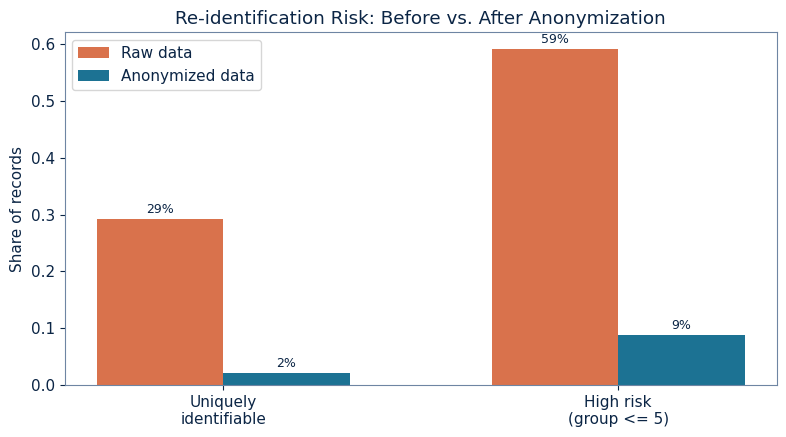

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ["Uniquely\nidentifiable", "High risk\n(group <= 5)"]
raw_vals = [pct_unique, pct_risky]
anon_vals = [pct_unique_anon, pct_risky_anon]

x = np.arange(len(labels))
width = 0.32
ax.bar(x - width/2, raw_vals, width, label="Raw data", color=ALERT)
ax.bar(x + width/2, anon_vals, width, label="Anonymized data", color=TEAL)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Share of records")
ax.set_title("Re-identification Risk: Before vs. After Anonymization")
ax.legend()
for i, (r, a) in enumerate(zip(raw_vals, anon_vals)):
    ax.text(i - width/2, r + 0.01, f"{r:.0%}", ha="center", fontsize=9)
    ax.text(i + width/2, a + 0.01, f"{a:.0%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 2.3 — The trade-off: does anonymization cost us model utility?

In [19]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def encode_and_score(df, cols, target, label):
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_enc = enc.fit_transform(df[cols].astype(str))
    X_tr, X_te, y_tr, y_te = train_test_split(X_enc, target, test_size=0.25, random_state=42, stratify=target)
    clf = GradientBoostingClassifier(random_state=42)
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    print(f"{label}: accuracy using only quasi-identifiers = {acc:.3f}")
    return acc

acc_raw = encode_and_score(X_adult, quasi_identifiers, y_adult, "Raw quasi-identifiers")
acc_anon = encode_and_score(X_anon, quasi_identifiers, y_adult, "Anonymized quasi-identifiers")

print()
print(f"Utility cost of anonymization: {acc_raw - acc_anon:.3f} accuracy points")
print("A small utility cost for a large drop in re-identification risk is usually a good trade.")

Raw quasi-identifiers: accuracy using only quasi-identifiers = 0.811


Anonymized quasi-identifiers: accuracy using only quasi-identifiers = 0.809

Utility cost of anonymization: 0.002 accuracy points
A small utility cost for a large drop in re-identification risk is usually a good trade.


---
## Block 3 — Responsible AI: Fairness & Explainability

**Dataset:** NHANES-I Health Survey (~14,000 records) — a real health survey with age and sex
attributes, well suited to pairing fairness metrics with a SHAP explanation.

*(Session plan note: German Credit Data was originally proposed for this block, but that dataset
is hosted on UCI/OpenML, which this environment's network allowlist can't reach. NHANES-I is
bundled with the `shap` library and gives the same fairness + explainability workflow on real data.)*

**What we'll do:**
1. Train a mortality-risk classifier on a real clinical feature set
2. Slice accuracy and false-positive rate by sex
3. Compute demographic parity and equalized odds gaps
4. Generate a local SHAP explanation for one individual's prediction, plus a global summary

In [20]:
X_nhanes_full, y_nhanes_raw = shap.datasets.nhanesi()

# y > 0 means death was observed during the study window; y < 0 means the record was censored
# (the person was still alive at last follow-up). We build a binary "elevated mortality risk" label.
label_nhanes = (y_nhanes_raw > 0).astype(int)

feature_cols = [
    "sex_isFemale", "age", "physical_activity", "systolic_blood_pressure",
    "cholesterol", "bmi", "hemoglobin", "white_blood_cells",
]
X_nhanes = X_nhanes_full[feature_cols].copy()
X_nhanes = X_nhanes.fillna(X_nhanes.median(numeric_only=True))

print(f"Records: {X_nhanes.shape[0]}")
print(f"Positive rate (elevated mortality risk during study window): {label_nhanes.mean():.1%}")
X_nhanes.head()

Records: 14264
Positive rate (elevated mortality risk during study window): 33.0%


,sex_isFemale,age,physical_activity,systolic_blood_pressure,cholesterol,bmi,hemoglobin,white_blood_cells
20751,False,51,3,110.0,256.0,25.406803,16.0,10.1
20753,False,41,2,136.0,254.0,24.588331,14.1,6.3
20754,True,31,2,110.0,177.0,23.756502,12.0,7.8
20755,False,48,2,126.0,209.0,28.610011,12.7,5.1
20756,True,29,3,98.0,206.0,19.216489,12.3,5.2


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

Xn_train, Xn_test, yn_train, yn_test, idx_train, idx_test = train_test_split(
    X_nhanes, label_nhanes, X_nhanes.index, test_size=0.25, random_state=42, stratify=label_nhanes
)

health_model = GradientBoostingClassifier(random_state=42, n_estimators=150, max_depth=3)
health_model.fit(Xn_train, yn_train)

overall_acc = accuracy_score(yn_test, health_model.predict(Xn_test))
print(f"Overall test accuracy: {overall_acc:.3f}")
print("Looks solid in aggregate — now let's check whether it's equally solid across groups.")

Overall test accuracy: 0.827
Looks solid in aggregate — now let's check whether it's equally solid across groups.


### 3.1 — Slicing metrics by sex

Aggregate accuracy can hide very different error patterns for different groups. We use
`fairlearn.metrics.MetricFrame` to slice accuracy and false-positive rate by sex.

In [22]:
from fairlearn.metrics import MetricFrame, false_positive_rate, selection_rate

sex_test = X_nhanes.loc[idx_test, "sex_isFemale"].map({True: "Female", False: "Male"})
predictions_test = health_model.predict(Xn_test)

metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "false_positive_rate": false_positive_rate,
        "selection_rate": selection_rate,
    },
    y_true=yn_test,
    y_pred=predictions_test,
    sensitive_features=sex_test,
)

print("Metrics by sex:")
metric_frame.by_group

Metrics by sex:


,accuracy,false_positive_rate,selection_rate
sex_isFemale,,,
Female,0.841418,0.081607,0.219683
Male,0.804501,0.168553,0.433896


In [23]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

dp_gap = demographic_parity_difference(yn_test, predictions_test, sensitive_features=sex_test)
eo_gap = equalized_odds_difference(yn_test, predictions_test, sensitive_features=sex_test)

print(f"Demographic parity difference: {dp_gap:.3f}  (0 = identical positive-prediction rates across groups)")
print(f"Equalized odds difference:     {eo_gap:.3f}  (0 = identical TPR and FPR across groups)")

Demographic parity difference: 0.214  (0 = identical positive-prediction rates across groups)


Equalized odds difference:     0.151  (0 = identical TPR and FPR across groups)


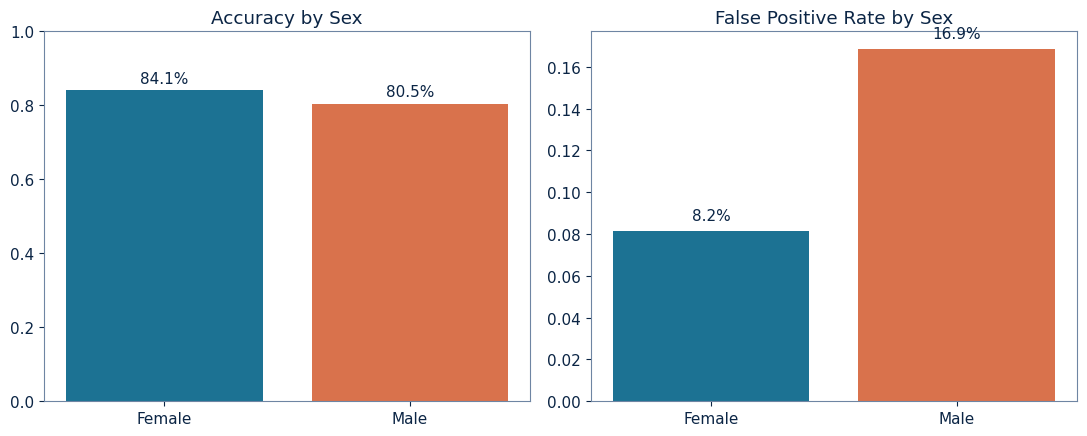

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
by_group = metric_frame.by_group

axes[0].bar(by_group.index, by_group["accuracy"], color=[TEAL, ALERT])
axes[0].set_title("Accuracy by Sex")
axes[0].set_ylim(0, 1)
for i, v in enumerate(by_group["accuracy"]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center")

axes[1].bar(by_group.index, by_group["false_positive_rate"], color=[TEAL, ALERT])
axes[1].set_title("False Positive Rate by Sex")
for i, v in enumerate(by_group["false_positive_rate"]):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

### 3.2 — Explaining predictions with SHAP: local and global

**Local** explanation: why did the model decide this, for this one person? **Global** explanation:
what drives the model's behavior overall? Both matter — fairness metrics tell us *whether* a gap
exists; explanations help us understand *why*.

Explaining prediction for test record #3
Predicted class: 0  |  Actual label: 0


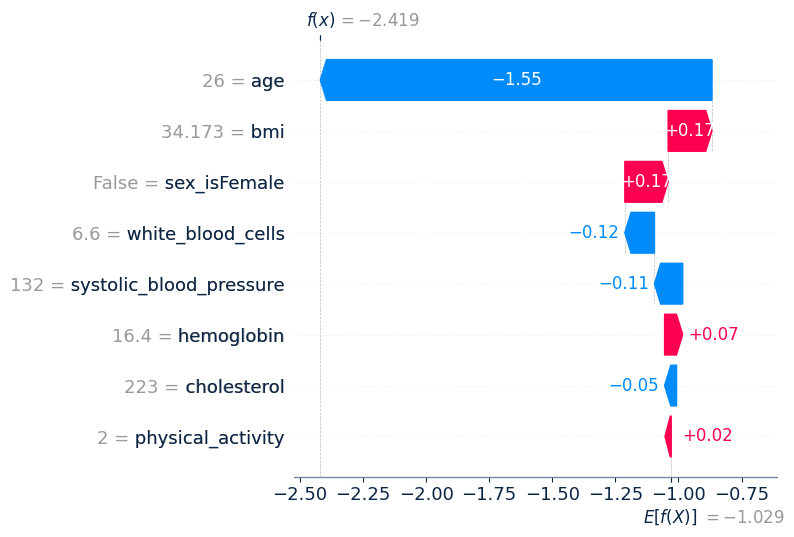

In [25]:
import shap as shap_lib

explainer = shap_lib.TreeExplainer(health_model)
shap_values = explainer(Xn_test)

# LOCAL: explain one individual test record
sample_idx = 3
print(f"Explaining prediction for test record #{sample_idx}")
print(f"Predicted class: {predictions_test[sample_idx]}  |  Actual label: {yn_test[sample_idx]}")

shap_lib.plots.waterfall(shap_values[sample_idx], show=False)
plt.tight_layout()
plt.show()

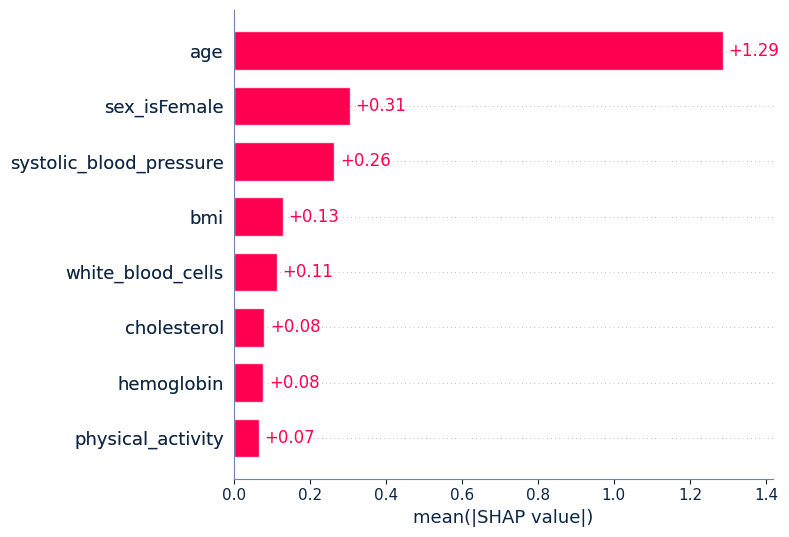

In [26]:
# GLOBAL: feature importance across all test records
shap_lib.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.show()

---
## Block 4 — Case Study: Drift + Fairness Monitoring

**Dataset:** Diabetes (scikit-learn, 442 patients, 10 physiological features). We split the
cohort by a real feature (age) to simulate a genuine distributional shift over "time" — the same
structure as the case study in the deck, where the applicant population skewed older over six months.

**What we'll do:**
1. Train on an earlier ("launch") age slice, evaluate on a later ("month 6") age slice
2. Track the accuracy drop and a simple drift signal (PSI) across the split
3. Compute a fairness-style gap (false-positive rate by sex) on the drifted evaluation slice
4. Apply a constrained retrain and compare accuracy vs. fairness before/after

In [27]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
X_diab = diabetes.data.copy()
y_diab_continuous = diabetes.target

# Binarize: "high disease progression" = above the median
y_diab = (y_diab_continuous > y_diab_continuous.median()).astype(int)

# Use age to define two cohorts, simulating a population that skews older over time
age_median = X_diab["age"].median()
cohort_launch = X_diab["age"] <= age_median   # "at launch" population
cohort_month6 = X_diab["age"] > age_median    # "month 6" population, skewed older

print(f"Launch cohort size:  {cohort_launch.sum()}")
print(f"Month-6 cohort size:  {cohort_month6.sum()}")

Launch cohort size:  227
Month-6 cohort size:  215


### 4.1 — Detecting the drift

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

feature_cols_diab = ["bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]

X_launch, y_launch = X_diab.loc[cohort_launch, feature_cols_diab], y_diab.loc[cohort_launch]
X_month6, y_month6 = X_diab.loc[cohort_month6, feature_cols_diab], y_diab.loc[cohort_month6]

X_launch_train, X_launch_test, y_launch_train, y_launch_test = train_test_split(
    X_launch, y_launch, test_size=0.3, random_state=42, stratify=y_launch
)

drift_model = LogisticRegression(max_iter=1000)
drift_model.fit(X_launch_train, y_launch_train)

acc_in_distribution = accuracy_score(y_launch_test, drift_model.predict(X_launch_test))
acc_month6 = accuracy_score(y_month6, drift_model.predict(X_month6))

print(f"Accuracy on held-out LAUNCH data (in-distribution): {acc_in_distribution:.3f}")
print(f"Accuracy on MONTH-6 data (shifted population):      {acc_month6:.3f}")
print(f"Accuracy drop from drift:                            {acc_in_distribution - acc_month6:.3f}")

Accuracy on held-out LAUNCH data (in-distribution): 0.681
Accuracy on MONTH-6 data (shifted population):      0.553
Accuracy drop from drift:                            0.128


In [29]:
def population_stability_index(expected, actual, bins=10):
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    expected_pct = np.clip(expected_pct, 1e-4, None)
    actual_pct = np.clip(actual_pct, 1e-4, None)
    return np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))

for feat in ["bmi", "bp"]:
    psi = population_stability_index(X_launch[feat].values, X_month6[feat].values)
    flag = "SIGNIFICANT SHIFT" if psi > 0.2 else ("moderate shift" if psi > 0.1 else "stable")
    print(f"PSI for '{feat}': {psi:.3f}  -> {flag}")

PSI for 'bmi': 0.441  -> SIGNIFICANT SHIFT
PSI for 'bp': 0.554  -> SIGNIFICANT SHIFT


### 4.2 — The hidden cost: checking fairness on the drifted evaluation

In [30]:
from fairlearn.metrics import MetricFrame, false_positive_rate

sex_month6 = X_diab.loc[cohort_month6, "sex"].map(lambda v: "Group A" if v < 0 else "Group B")
predictions_month6 = drift_model.predict(X_month6)

fairness_before = MetricFrame(
    metrics={"accuracy": accuracy_score, "false_positive_rate": false_positive_rate},
    y_true=y_month6, y_pred=predictions_month6, sensitive_features=sex_month6,
)

print("Fairness metrics on month-6 data, BEFORE any fix:")
fairness_before.by_group

Fairness metrics on month-6 data, BEFORE any fix:


,accuracy,false_positive_rate
sex,,
Group A,0.505155,0.000000
Group B,0.593220,0.019608


In [31]:
from fairlearn.metrics import equalized_odds_difference

eo_gap_before = equalized_odds_difference(y_month6, predictions_month6, sensitive_features=sex_month6)
print(f"Equalized odds gap BEFORE fix: {eo_gap_before:.3f}")

Equalized odds gap BEFORE fix: 0.126


### 4.3 — Retraining with a fairness constraint

In [32]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

X_month6_retrain, X_month6_holdout, y_month6_retrain, y_month6_holdout, sex_retrain, sex_holdout = (
    train_test_split(X_month6, y_month6, sex_month6, test_size=0.5, random_state=42, stratify=y_month6)
)

X_retrain_combined = pd.concat([X_launch_train, X_month6_retrain])
y_retrain_combined = pd.concat([y_launch_train, y_month6_retrain])
sex_retrain_combined = pd.concat([
    X_diab.loc[X_launch_train.index, "sex"].map(lambda v: "Group A" if v < 0 else "Group B"),
    sex_retrain,
])

fair_model = ExponentiatedGradient(
    estimator=LogisticRegression(max_iter=1000),
    constraints=EqualizedOdds(),
)
fair_model.fit(X_retrain_combined, y_retrain_combined, sensitive_features=sex_retrain_combined)

predictions_fair = fair_model.predict(X_month6_holdout)
acc_after = accuracy_score(y_month6_holdout, predictions_fair)
eo_gap_after = equalized_odds_difference(y_month6_holdout, predictions_fair, sensitive_features=sex_holdout)

accuracy_only_model = LogisticRegression(max_iter=1000)
accuracy_only_model.fit(X_retrain_combined, y_retrain_combined)
predictions_acc_only = accuracy_only_model.predict(X_month6_holdout)
acc_accuracy_only = accuracy_score(y_month6_holdout, predictions_acc_only)
eo_gap_accuracy_only = equalized_odds_difference(y_month6_holdout, predictions_acc_only, sensitive_features=sex_holdout)

print(f"{'Approach':<32}{'Accuracy':>12}{'Equalized Odds Gap':>22}")
print(f"{'Accuracy-only retrain':<32}{acc_accuracy_only:>12.3f}{eo_gap_accuracy_only:>22.3f}")
print(f"{'Fairness-constrained retrain':<32}{acc_after:>12.3f}{eo_gap_after:>22.3f}")

Approach                            Accuracy    Equalized Odds Gap
Accuracy-only retrain                  0.750                 0.280
Fairness-constrained retrain           0.657                 0.180


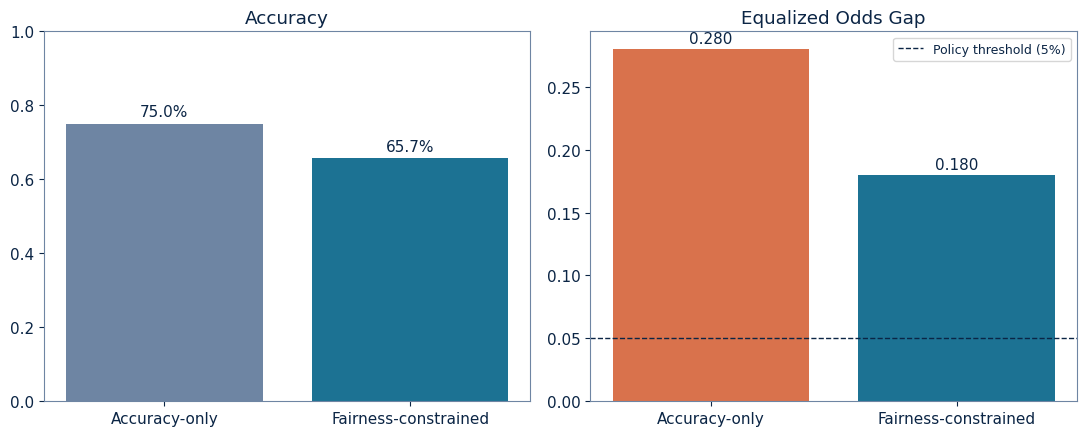


This is the accuracy-vs-fairness trade-off from the case study, reproduced on real data:
the fairness-constrained retrain accepts a small accuracy change in exchange for a smaller gap.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
approaches = ["Accuracy-only", "Fairness-constrained"]

axes[0].bar(approaches, [acc_accuracy_only, acc_after], color=[MUTED, TEAL])
axes[0].set_title("Accuracy")
axes[0].set_ylim(0, 1)
for i, v in enumerate([acc_accuracy_only, acc_after]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center")

axes[1].bar(approaches, [eo_gap_accuracy_only, eo_gap_after], color=[ALERT, TEAL])
axes[1].axhline(0.05, color=NAVY, linestyle="--", linewidth=1, label="Policy threshold (5%)")
axes[1].set_title("Equalized Odds Gap")
axes[1].legend(fontsize=9)
for i, v in enumerate([eo_gap_accuracy_only, eo_gap_after]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

print()
print("This is the accuracy-vs-fairness trade-off from the case study, reproduced on real data:")
print("the fairness-constrained retrain accepts a small accuracy change in exchange for a smaller gap.")

### 4.4 — Interactive: exploring the threshold trade-off

In [34]:
import ipywidgets as widgets
from IPython.display import display

probs_holdout = accuracy_only_model.predict_proba(X_month6_holdout)[:, 1]

def explore_threshold(threshold=0.5):
    preds = (probs_holdout >= threshold).astype(int)
    acc = accuracy_score(y_month6_holdout, preds)
    gap = equalized_odds_difference(y_month6_holdout, preds, sensitive_features=sex_holdout)
    bar_color = TEAL if gap <= 0.05 else ALERT
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.barh(["Accuracy", "Equalized odds gap"], [acc, gap], color=[TEAL, bar_color])
    ax.set_xlim(0, 1)
    ax.axvline(0.05, color=NAVY, linestyle="--", linewidth=1)
    ax.set_title(f"Decision threshold = {threshold:.2f}")
    for i, v in enumerate([acc, gap]):
        ax.text(v + 0.02, i, f"{v:.3f}", va="center")
    plt.tight_layout()
    plt.show()

widgets.interact(explore_threshold, threshold=widgets.FloatSlider(value=0.5, min=0.1, max=0.9, step=0.05));

interactive(children=(FloatSlider(value=0.5, description='threshold', max=0.9, min=0.1, step=0.05), Output()),…

---
## Summary

Each block demonstrated concrete techniques from the corresponding deck section, on real data:

1. **Model Security** — extraction attack, membership inference, data poisoning, OOD detection,
   and a query-rate anomaly detector — one demo per threat bucket
2. **Data Privacy** — quantified re-identification risk before/after anonymization, and its utility cost
3. **Responsible AI** — a fairness gap hidden inside a good aggregate accuracy number, explained
   locally (one prediction) and globally (overall feature importance) with SHAP
4. **Case Study** — drift detection, a fairness gap that drift can introduce, and two ways to fix it

These are teaching-scale demonstrations — production systems need continuous monitoring pipelines,
not one-off notebook runs, but the underlying techniques are the same ones used in practice.